# Domain Problem

Is there a correlation between diagnosis of diabetes and external complications?

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
filename = r"C:\Users\risha\Cornell University\Intro to Data Science\ORIE5160\ORIE-5160-Midterm-Project\data\samadult.csv"

In [5]:
diabetes_pd = pd.read_csv(filename)
diabetes_pd

,FPX,FMX,HHX,INTV_QRT,WTIA_SA,WTFA_SA,SEX,HISPAN_I,R_MARITL,MRACRPI2,...,BFWH_05,BFWH_06,BFWH_07,BFWH_08,BFWH_09,BFWH_10,BNRFALL,BINTHI,BINTTR,BINTRS
0,1,1,1,1,11241.0,26100,1,12,8,2,...,2.0,2.0,2.0,2.0,1.0,2.0,5.0,2.0,2.0,2.0
1,1,2,1,1,5620.5,11294,2,12,5,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,1,2,1,2919.3,2506,1,12,5,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2,1,3,1,8883.8,9267,2,3,2,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,1,5,1,3300.8,3443,2,3,7,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33023,1,1,71559,4,3674.3,4433,1,12,5,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
33024,1,1,71565,4,8485.0,10236,1,12,8,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
33025,1,1,71569,4,8454.9,8505,2,12,1,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
33026,1,1,71576,4,5261.4,6347,1,12,5,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Feature Engineering 
- Create groups that we want to test
- Group A (Has diabetes) Group B (No diabetes)
- Determine proportion of complication type for each group 

#### Drop row values for "DIBEV1" that are null, or responded with "I don't know"

In [6]:
# Drop rows with 'DIBEV1' values of 7, 8, or 9 directly on the dataframe
diabetes_pd2 = diabetes_pd[diabetes_pd['DIBEV1'].apply(lambda x: x not in [7, 8, 9])]

diabetes_pd2['DIBEV1'].isnull().sum()

0

#### Create a list of complications

In [7]:
complications = ['HYPEV', 'CHLEV', 'CHDEV', 'ANGEV', 'MIEV', 'HRTEV', 'STREV', 'EPHEV',
 'COPDEV', 'AASMEV', 'ULCEV', 'ULCCOLEV', 'CANEV', 'SINYR', 'CBRCHYR',
 'KIDWKYR', 'LIVYR', 'ARTH1', 'VIM_GLEV']

In [8]:
# Drop rows with values 7, 8, 9 or null for complication variables
diabetes_pd3 = diabetes_pd2[~diabetes_pd2[complications].isin([7, 8, 9]).any(axis=1)]
diabetes_pd3 = diabetes_pd3.dropna(subset=complications)
diabetes_pd3.shape

(32580, 805)

#### Plot the proportion complication

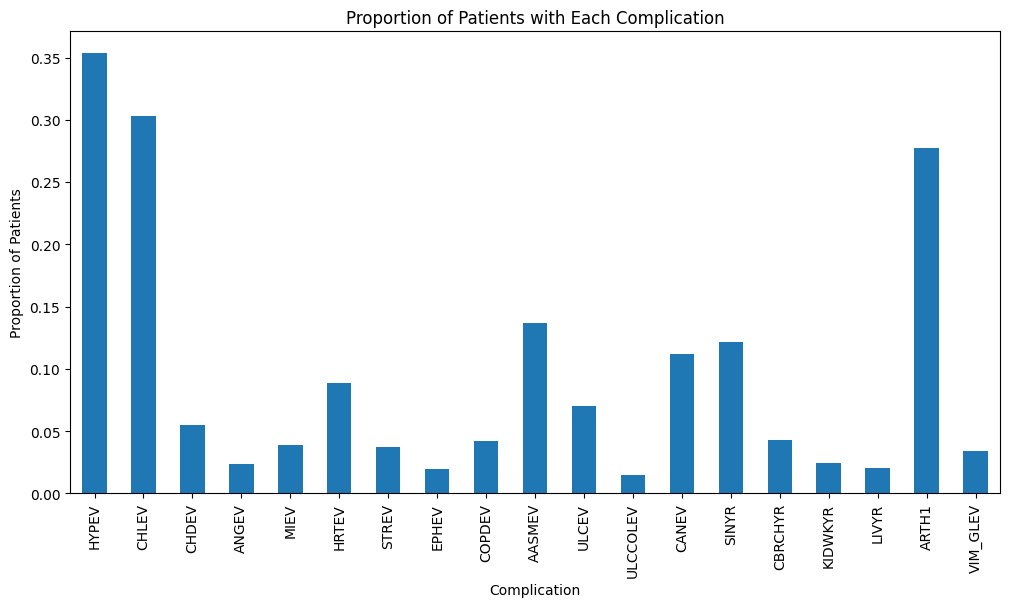

In [9]:
complication_proportions = diabetes_pd2[complications].apply(lambda x: (x == 1).mean())

# Plotting the bar graph
plt.figure(figsize=(12, 6))
complication_proportions.plot(kind='bar')

# Setting title and labels
plt.title('Proportion of Patients with Each Complication')
plt.xlabel('Complication')
plt.ylabel('Proportion of Patients')

# Display the plot
plt.show()

As shown in the graph, the following variables appear to be the most significant complications:
1) HYPEV
2) CHLEV
3) HRTEV
4) AASMEV
5) ARTH1


#### Find relevant features for grouping - need to add insurance still

In [10]:
grouping_features = [
    'AGE_P',           # Age of the individual
    'SEX',             # Gender
    'RACERPI2',        # Detailed race group
    'R_MARITL',        # Marital status
    'ONEJOB',          # More than one job
    'SMKEV',           # Ever smoked at least 100 cigarettes in lifetime
    'REGION',          # U.S. region
    'PAR_STAT',        # Parental status
    'WRKCATA',         # Job type or work category
    'AINDDIF2',        # Difficulty in finding affordable health insurance
    'AWEIGHTP',        # Body Weight
    'AFLHC29_'         # If Alcohol consumption has caused difficulties
]

# Display the list
grouping_features


['AGE_P',
 'SEX',
 'RACERPI2',
 'R_MARITL',
 'ONEJOB',
 'SMKEV',
 'REGION',
 'PAR_STAT',
 'WRKCATA',
 'AINDDIF2',
 'AWEIGHTP',
 'AFLHC29_']

#### Check to see if features have any null values

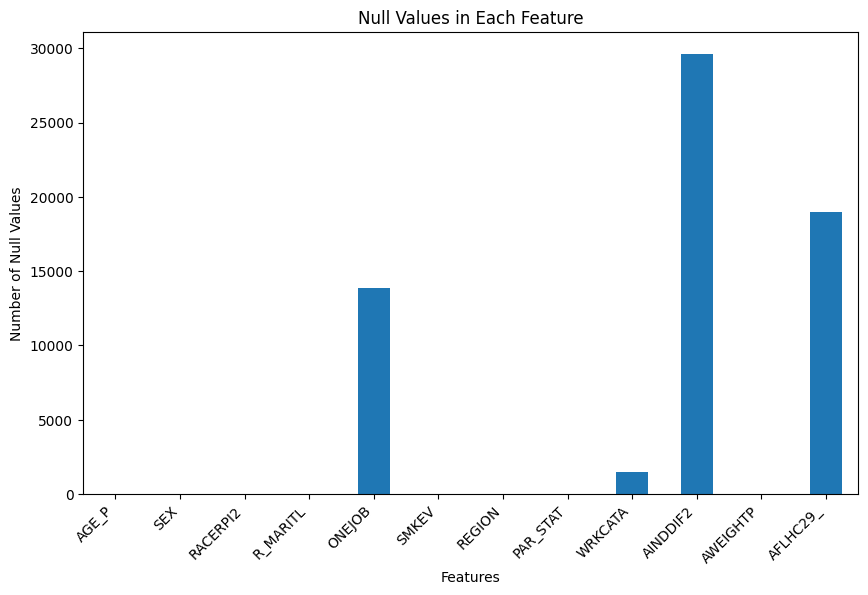

In [11]:
null_counts = diabetes_pd3[grouping_features].isnull().sum()

# Plotting the bar graph
plt.figure(figsize=(10, 6))
null_counts.plot(kind='bar')
plt.title("Null Values in Each Feature")
plt.xlabel("Features")
plt.ylabel("Number of Null Values")
plt.xticks(rotation=45, ha='right')
plt.show()

Will drop features with high null values

In [13]:
grouping_features2 = [
    'AGE_P',           
    'SEX',              
    'RACERPI2',        # Drop 05 values (Race group not releasable)
    'R_MARITL',        # Drop 9 - unknown status
    'SMKEV',           # Drop 7,8,9
    'REGION',          
    'PAR_STAT',        # Drop 9 
    'WRKCATA',         # Drop 7,8,9
    'AWEIGHTP',        # Drop 996 - 999
]

# Display the list
grouping_features2


['AGE_P',
 'SEX',
 'RACERPI2',
 'R_MARITL',
 'SMKEV',
 'REGION',
 'PAR_STAT',
 'WRKCATA',
 'AWEIGHTP']

#### Clean dataframe by filtered rows with unknown values for selected features

In [14]:
filter_group1 = (
    (diabetes_pd3['RACERPI2'] != 5) &              # Drop value 5
    (diabetes_pd3['R_MARITL'] != 9) &              # Drop value 9 (unknown marital status)
    (diabetes_pd3['SMKEV'].isin([7, 8, 9]) == False) &  # Drop values 7, 8, 9
    (diabetes_pd3['PAR_STAT'] != 9) &              # Drop value 9
    (diabetes_pd3['WRKCATA'].isin([7, 8, 9]) == False) & # Drop values 7, 8, 9
    (diabetes_pd3['DIBEV1'].isin([7, 8, 9]) == False) &
    (diabetes_pd3['AWEIGHTP'] < 996)               # Drop values 996-999
)

# Applying the filter and dropping rows with null values in the specified features
diabetes_df4 = diabetes_pd3[filter_group1].dropna(subset=grouping_features2)

# Display the first few rows of the cleaned DataFrame to confirm changes
diabetes_df4.shape


(28110, 805)

In [15]:
# Convert all values of 2 to 0 in the specified complications columns in diabetes_df4
diabetes_df4[complications] = diabetes_df4[complications].replace(2, 0)

# Display the first few rows to confirm the conversion
diabetes_df4[complications].head()


,HYPEV,CHLEV,CHDEV,ANGEV,MIEV,HRTEV,STREV,EPHEV,COPDEV,AASMEV,ULCEV,ULCCOLEV,CANEV,SINYR,CBRCHYR,KIDWKYR,LIVYR,ARTH1,VIM_GLEV
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


#### As of now, we have cleaned the dataframe by removing null values and "unknown" sample recordings for complications and feature selection for our first grouping

### Now lets create a function to seperate the groups

In [16]:
def filter_diabetes_data(df, age_range=None, sex=None, race=None, smoked=None, parent_status=None, employee_status=None, weight_range=None):
    """
    Filters the DataFrame based on provided criteria for each feature.
    
    Parameters:
    - df (DataFrame): The DataFrame to filter.
    - age_range (tuple): Minimum and maximum age (e.g., (20, 40)).
    - sex (int): Sex code (e.g., 1 for male).
    - race (int): Race code (e.g., 1 for White only).
    - smoked (int): Smoking status code (e.g., 2 for never smoked 100 cigarettes).
    - parent_status (int): Parental status code (e.g., 1 for parent).
    - employee_status (list): List of employment status codes to include (e.g., [1, 2, 3, 4]).
    - weight_range (tuple): Minimum and maximum weight (e.g., (120, 250)).

    Returns:
    - DataFrame: A filtered DataFrame based on the provided criteria.
    """
    # Reset index and explicitly align the index of the filter criteria
    df = df.reset_index(drop=True)
    filter_criteria = pd.Series([True] * len(df))
    filter_criteria.index = df.index  # Align the boolean series index with df
    
    # Apply conditions based on the provided arguments
    if age_range:
        filter_criteria &= (df['AGE_P'] >= age_range[0]) & (df['AGE_P'] <= age_range[1])
    if sex is not None:
        filter_criteria &= (df['SEX'] == sex)
    if race is not None:
        filter_criteria &= (df['RACERPI2'] == race)
    if smoked is not None:
        filter_criteria &= (df['SMKEV'] == smoked)
    if parent_status is not None:
        filter_criteria &= (df['PAR_STAT'] == parent_status)
    if employee_status:
        filter_criteria &= df['WRKCATA'].isin(employee_status)
    if weight_range:
        filter_criteria &= (df['AWEIGHTP'] >= weight_range[0]) & (df['AWEIGHTP'] <= weight_range[1])
    
    # Return the filtered DataFrame
    return df[filter_criteria]


### Now lets create our groups

- Age 
- Sex 
- Race 
- Smoke over 100 cigarettes
- Is a parent
- Is an employee
- At a relatively healthy weight without knowing the height (120 - 250)

Will first start with a larger group: (Group1)

- Age 20-50
- Has not smoked over 100 cigarettes in lifetime
- Is employeed

In [24]:
group1 = filter_diabetes_data(
    diabetes_df4, 
    age_range=(20, 50), 
    sex=None, 
    race=None, 
    smoked=2, 
    parent_status=None,  # Ignoring parent status
    employee_status=[1, 2, 3, 4], 
    weight_range=(120, 250)
)


In [30]:
group1.shape

(7025, 805)

In [31]:
group1.to_csv('group1.csv')

Group 2 will be the same parameters, but will now consist of only **females** - stability check

In [32]:
group2_female = filter_diabetes_data(
    diabetes_df4, 
    age_range=(20, 50), 
    sex=2, 
    race=1, 
    smoked=2, 
    parent_status=1, 
    employee_status=[1, 2, 3, 4], 
    weight_range=(120, 250)
)

In [33]:
group2_female.shape

(1484, 805)

In [34]:
group2_female.to_csv('group2_female.csv')

Group 3: Younger age group

In [35]:
group3 = filter_diabetes_data(
    diabetes_df4, 
    age_range=(0, 30), 
    sex=None, 
    race=None, 
    smoked=None, 
    parent_status=None,  # Ignoring parent status
    employee_status= None, 
    weight_range=None
)


In [36]:
group3.to_csv('group3.csv')

Group 4: Invdivisuals identify themselves as whiten only

In [37]:
group4 = filter_diabetes_data(
    diabetes_df4, 
    age_range= None, 
    sex=None, 
    race=1, 
    smoked=None, 
    parent_status=None,  # Ignoring parent status
    employee_status= None, 
    weight_range=None
)

In [38]:
group4.to_csv('group4.csv')

Group 5: Sample size of all race except for white

In [39]:
group5 = diabetes_df4[diabetes_df4['RACERPI2'] != 1]

In [40]:
group5.to_csv('group5.csv')